# Lesson 29: PyTorch neural network demonstration part 2

In this notebook, we build a deep neural network (DNN) classifier for the [CIFAR-10 dataset](https://cave.cs.toronto.edu/kriz/cifar.html) using PyTorch's `nn.Sequential` module. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes. We convert the images to grayscale (single channel) and use only fully connected layers (no convolution or pooling) to demonstrate the fundamentals of deep learning classification.

## Notebook set-up

### Imports

In [1]:
import torch
print(torch.__version__)  # should still show 2.5.1 without +cu124 if replaced
print(torch.cuda.is_available())
# Run this to see which torch binary is being used:
import inspect; print(inspect.getfile(torch))

2.5.1
True
/usr/local/lib/python3.10/dist-packages/torch/__init__.py


In [2]:
# Standard library imports
from pathlib import Path

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Set random seeds for reproducibility
torch.manual_seed(315)
np.random.seed(315)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Configuration

In [3]:
# Directory to store image data
data_dir = Path('../data')
data_dir.mkdir(parents=True, exist_ok=True)

### Hyperparameters

In [4]:
batch_size = 2500 # Images come in batches of 10,000 already
learning_rate = 5e-4
epochs = 200
print_every = 10 # Print training progress every n epochs

## 1. Load and preprocess CIFAR-10 data

CIFAR-10 contains 32x32 color images (3 channels) across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. We convert the images to grayscale for this demonstration.

### 1.1. Define transformations

In [5]:
# Define class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Data preprocessing: convert to grayscale, tensor, and normalize
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

### 1.2. Load datasets

In [6]:
# Load training and test datasets
train_dataset = datasets.CIFAR10(
    root=data_dir,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Image shape: {train_dataset[0][0].shape}')
print(f'Number of classes: {len(class_names)}')

Files already downloaded and verified
Files already downloaded and verified
Training samples: 50000
Test samples: 10000
Image shape: torch.Size([1, 32, 32])
Number of classes: 10


### 1.3. Pre-load data and create data loaders

In [7]:
# Pre-load entire dataset to device for faster training
X_train_full = torch.stack([img for img, _ in train_dataset]).to(device)
y_train_full = torch.tensor([label for _, label in train_dataset]).to(device)

X_test = torch.stack([img for img, _ in test_dataset]).to(device)
y_test = torch.tensor([label for _, label in test_dataset]).to(device)

# Split training data into train and validation sets (80/20 split)
n_train = int(0.8 * len(X_train_full))
indices = torch.randperm(len(X_train_full))

X_train = X_train_full[indices[:n_train]]
y_train = y_train_full[indices[:n_train]]
X_val = X_train_full[indices[n_train:]]
y_val = y_train_full[indices[n_train:]]

print(f'X_train shape: {X_train.shape}, device: {X_train.device}')
print(f'y_train shape: {y_train.shape}, device: {y_train.device}')
print(f'X_val shape: {X_val.shape}, device: {X_val.device}')
print(f'y_val shape: {y_val.shape}, device: {y_val.device}')
print(f'X_test shape: {X_test.shape}, device: {X_test.device}')
print(f'y_test shape: {y_test.shape}, device: {y_test.device}')

X_train shape: torch.Size([40000, 1, 32, 32]), device: cuda:0
y_train shape: torch.Size([40000]), device: cuda:0
X_val shape: torch.Size([10000, 1, 32, 32]), device: cuda:0
y_val shape: torch.Size([10000]), device: cuda:0
X_test shape: torch.Size([10000, 1, 32, 32]), device: cuda:0
y_test shape: torch.Size([10000]), device: cuda:0


In [8]:
# Create TensorDatasets
train_tensor_dataset = torch.utils.data.TensorDataset(X_train, y_train)
val_tensor_dataset = torch.utils.data.TensorDataset(X_val, y_val)
test_tensor_dataset = torch.utils.data.TensorDataset(X_test, y_test)

# Create DataLoaders
train_loader = DataLoader(
    train_tensor_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_tensor_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_tensor_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Training batches: 16
Validation batches: 4
Test batches: 4


### 1.4. Visualize sample images

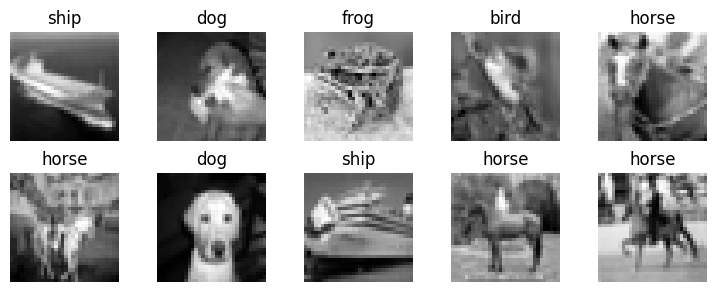

In [9]:
# Get a batch of training images
images, labels = next(iter(train_loader))

# Plot first 10 images
ncols = 5
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*1.5, nrows*1.5))
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Unnormalize and squeeze for plotting (move to CPU first)
    img = images[i].cpu() * 0.5 + 0.5
    img = img.numpy().squeeze()
    ax.set_title(class_names[labels[i]])
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Build DNN classifier with nn.Sequential

We build a fully connected deep neural network using `nn.Sequential`. Since we are not using convolutional layers, we flatten the 32x32x1 grayscale images into a 1024-dimensional vector.

### 2.1. Define model architecture

In [10]:
# Input size: 32 x 32 x 1 = 1024 (grayscale)
input_size = 32 * 32 * 1
num_classes = 10

model = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(input_size, 2048),
    nn.ReLU(),
    nn.Dropout(0.7),
    nn.Linear(2048, 1024),
    nn.ReLU(),
    nn.Dropout(0.7),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.7),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.45),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(32, num_classes)
).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {trainable_params}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Dropout(p=0.5, inplace=False)
  (2): Linear(in_features=1024, out_features=2048, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.7, inplace=False)
  (5): Linear(in_features=2048, out_features=1024, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.7, inplace=False)
  (8): Linear(in_features=1024, out_features=512, bias=True)
  (9): ReLU()
  (10): Dropout(p=0.7, inplace=False)
  (11): Linear(in_features=512, out_features=128, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.45, inplace=False)
  (14): Linear(in_features=128, out_features=32, bias=True)
  (15): ReLU()
  (16): Dropout(p=0.25, inplace=False)
  (17): Linear(in_features=32, out_features=10, bias=True)
)

Total parameters: 4792298


### 2.2. Define loss function and optimizer

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### 2.3. Define training function

In [12]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    epochs: int = 10,
    print_every: int = 1
) -> dict[str, list[float]]:
    '''Training loop for PyTorch classification model.
    
    Note: Assumes data is already on the correct device.
    '''

    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track metrics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        # Record metrics
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_accuracy'].append(val_accuracy)

        # Print progress
        if (epoch + 1) % print_every == 0 or epoch == 0:

            print(
                f'Epoch {epoch+1}/{epochs} - ' +
                f'loss: {train_loss:.4f} - ' +
                f'accuracy: {train_accuracy:.2f}% - ' +
                f'val_loss: {val_loss:.4f} - ' +
                f'val_accuracy: {val_accuracy:.2f}%'
            )

    print('\nTraining complete.')

    return history

### 2.4. Train model

In [13]:
%%time

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=epochs,
    print_every=print_every
)

Epoch 1/200 - loss: 2.3008 - accuracy: 10.54% - val_loss: 2.2745 - val_accuracy: 14.24%
Epoch 10/200 - loss: 2.0097 - accuracy: 26.77% - val_loss: 1.9120 - val_accuracy: 31.73%
Epoch 20/200 - loss: 1.8897 - accuracy: 32.47% - val_loss: 1.7837 - val_accuracy: 36.68%
Epoch 30/200 - loss: 1.8181 - accuracy: 35.60% - val_loss: 1.7191 - val_accuracy: 39.12%
Epoch 40/200 - loss: 1.7780 - accuracy: 37.15% - val_loss: 1.6719 - val_accuracy: 40.67%
Epoch 50/200 - loss: 1.7410 - accuracy: 38.45% - val_loss: 1.6506 - val_accuracy: 41.62%
Epoch 60/200 - loss: 1.7108 - accuracy: 39.88% - val_loss: 1.6184 - val_accuracy: 42.54%
Epoch 70/200 - loss: 1.6827 - accuracy: 40.80% - val_loss: 1.6010 - val_accuracy: 43.29%
Epoch 80/200 - loss: 1.6722 - accuracy: 41.34% - val_loss: 1.6033 - val_accuracy: 43.26%
Epoch 90/200 - loss: 1.6495 - accuracy: 42.13% - val_loss: 1.5917 - val_accuracy: 43.58%
Epoch 100/200 - loss: 1.6359 - accuracy: 42.55% - val_loss: 1.5702 - val_accuracy: 44.66%
Epoch 110/200 - loss:

### 2.5. Learning curves

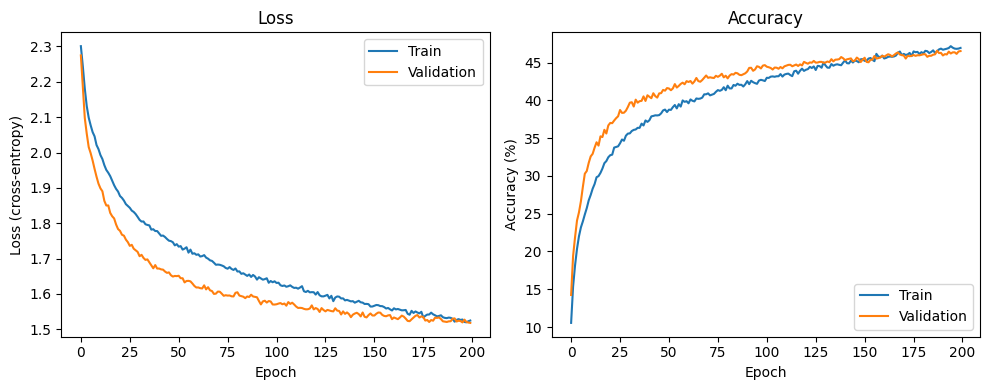

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Loss')
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].legend(loc='best')

axes[1].set_title('Accuracy')
axes[1].plot(history['train_accuracy'], label='Train')
axes[1].plot(history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

## 3. Evaluate model on test set

### 3.1. Calculate test accuracy

In [15]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader
) -> tuple[float, np.ndarray, np.ndarray]:
    '''Evaluate model on test set.
    
    Note: Assumes data is already on the correct device.
    '''

    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, np.array(all_predictions), np.array(all_labels)

test_accuracy, predictions, true_labels = evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 47.61%


### 3.2. Per-class accuracy

In [16]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in class_names}
class_total = {name: 0 for name in class_names}

for pred, true in zip(predictions, true_labels):

    class_name = class_names[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in class_names:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 43.40%
automobile  : 55.00%
bird        : 38.10%
cat         : 24.30%
deer        : 46.80%
dog         : 42.40%
frog        : 59.10%
horse       : 52.10%
ship        : 68.70%
truck       : 46.20%


### 3.3. Visualize predictions

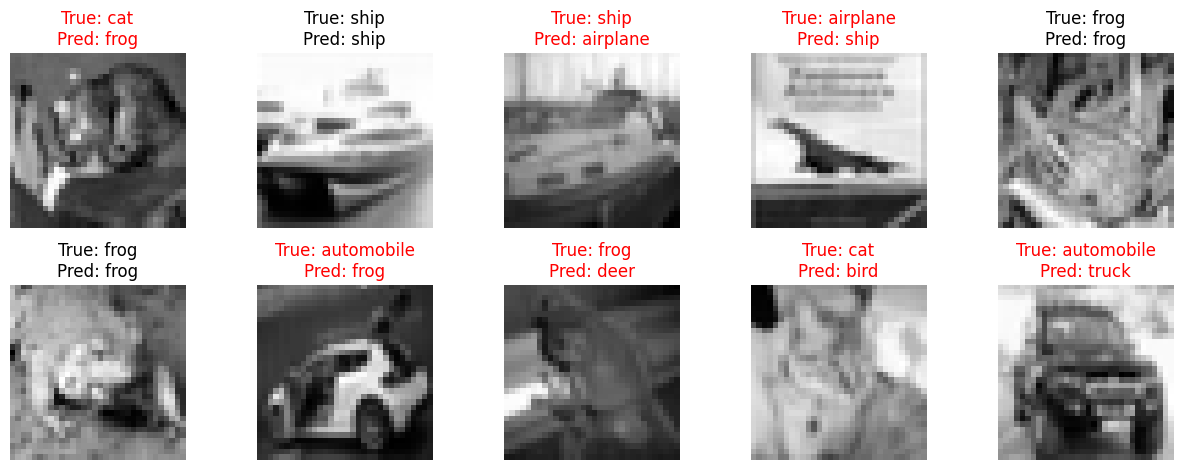

In [17]:
# Get a batch of test images
test_images, test_labels = next(iter(test_loader))

# Make predictions
model.eval()

with torch.no_grad():
    test_outputs = model(test_images)
    _, test_preds = torch.max(test_outputs, 1)

test_preds = test_preds.cpu().numpy()

# Plot first 10 images with predictions
ncols = 5
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.5, nrows*2.4))
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Unnormalize and squeeze for plotting (move to CPU first)
    img = test_images[i].cpu() * 0.5 + 0.5
    img = img.numpy().squeeze()

    true_label = class_names[test_labels[i]]
    pred_label = class_names[test_preds[i]]
    color = 'black' if true_label == pred_label else 'red'

    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3.4. Confusion matrix

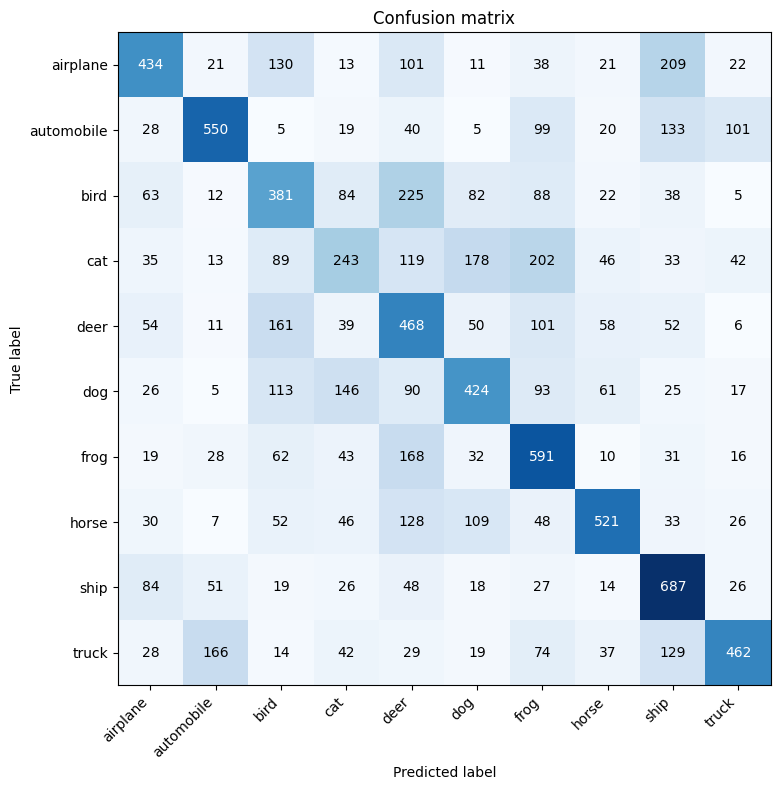

In [18]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_title('Confusion matrix')
im = ax.imshow(cm, cmap='Blues')

# Add labels
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

# Add text annotations
for i in range(len(class_names)):

    for j in range(len(class_names)):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color)

plt.tight_layout()
plt.show()

## 4. Summary

In this notebook, we built a deep neural network classifier for CIFAR-10 using PyTorch's `nn.Sequential` module. Key observations:

- Images are converted to grayscale (single channel) before processing
- The model uses only fully connected (dense) layers with no convolution or pooling
- Input images are flattened from 32x32x1 (1024 features) before being passed to the network
- Dropout layers help prevent overfitting
- Without convolutional layers, the model has limited ability to learn spatial features, resulting in lower accuracy compared to CNN-based approaches
- This demonstrates the importance of using appropriate architectures (like CNNs) for image classification tasks

In [19]:
print(f'Final test accuracy: {test_accuracy:.2f}%')
print(f'Total model parameters: {sum(p.numel() for p in model.parameters()):,}')

Final test accuracy: 47.61%
Total model parameters: 4,792,298
